# Model Predictions and Visualization

This notebook loads trained convCNP models and visualizes predictions on holdout time periods.

For each fold, we:
1. Load the trained model checkpoint
2. Identify the holdout time period for that fold
3. Select one deterministic day from the holdout period
4. Generate predictions for all spatial points
5. Plot side-by-side heatmaps: Ground Truth | Predictions | Residuals

In [1]:
from collections import OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from params import Params, load_params_json
from datasets import (
    Era5Metadata,
    load_metadata_json,
    load_era5_data,
    load_high_res_topography,
    prepare_meteoswiss_targets,
    calculate_dists_meteoswiss,
    get_meteoswiss_grid_shape,
)
from convCNP.models.elev_models import TmaxBiasConvCNPElev, GammaBiasConvCNPElev
from convCNP.models.cnn import CNN, ResConvBlock
from convCNP.training.utils import get_value_tmax

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else
                      'cpu')
print(f'Using device: {device}')

Using device: cuda


## Configuration

Specify the trained model directory to load.

In [3]:
# Path to trained model directory
MODEL_DIR = Path('./trained_models/base-30-5folds-with-elev')

# Data paths (should match training)
# TODO: send these into the metadata at training, recover them here
ERA5_MAX_TEMP_GLOB = './datasets/ERA5_Land/max_temperature/*.nc'
ERA5_GEOPOTENTIAL_GLOB = './datasets/ERA5_Land/geopotential/*.nc'
METEO_SWISS_MAX_TEMP_GLOB = './datasets/MeteoSwiss/TmaxD_v2.0_swiss.lv95/*.nc'
HI_RES_TOPOGRAPHY_ZARR_PATH = './datasets/topo_subset.zarr'

## Load Training Configuration

In [4]:
# Load params and metadata from training
params = load_params_json(MODEL_DIR / 'params.json')
metadata = load_metadata_json(MODEL_DIR / 'metadata.json')

print(f"Loaded configuration for run: {params.TRIAL_NAME}")
print(f"  Variable: {params.VARIABLE}")
print(f"  Data year start: {params.DATA_YEAR_START}")
print(f"  N folds: {params.N_FOLDS}")
print(f"  Model: {params.N_CHANNELS} channels, {params.N_BLOCKS} blocks")

Loaded configuration for run: base-30-5folds-with-elev
  Variable: tmax
  Data year start: 2023
  N folds: 5
  Model: 128 channels, 6 blocks


## Load Data

In [5]:
# Load ERA5 input data with geopotential
era5_data, _, era5_grid_elevation = load_era5_data(
    ERA5_MAX_TEMP_GLOB,
    var_name='t2m_max',
    year_start=params.DATA_YEAR_START,
    geopotential_glob=ERA5_GEOPOTENTIAL_GLOB,
    device=device
)

print(f"ERA5 data shape: {era5_data.shape}")

# Load high-resolution topography
hi_res_elevation = load_high_res_topography(HI_RES_TOPOGRAPHY_ZARR_PATH)

Loading ERA5 data from: ./datasets/ERA5_Land/max_temperature/*.nc
Dataset loaded with dimensions: FrozenMappingWarningOnValuesAccess({'time': 23376, 'latitude': 29, 'longitude': 61})
Original dataset time range: 1960-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset time range from 2023: 2023-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 365, 'latitude': 29, 'longitude': 61})
Calculating stats for t2m_max (Kelvin)...
Final tensor_Z torch tensor with shape (time, channel, lat, lon): torch.Size([365, 5, 29, 61]), dtype: torch.float32

Loading geopotential data from: ./datasets/ERA5_Land/geopotential/*.nc
Geopotential dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 1, 'latitude': 51, 'longitude': 81})
Geopotential lat range: [44.0000, 49.0000], shape: (51,)
Geopotential lon range: [4.0000, 12.0000], shape: (81,)
ERA5 data lat range: [45.4000, 48.2000], shape: (29,)

In [6]:
# Load MeteoSwiss targets with elevation
target_x, target_y, target_topo = prepare_meteoswiss_targets(
    METEO_SWISS_MAX_TEMP_GLOB,
    normalization_stats=metadata,
    data_var='TmaxD',
    grid_elevation=era5_grid_elevation,
    hi_res_elevation=hi_res_elevation,
    convert_to_kelvin=True,
    year_start=params.DATA_YEAR_START,
    device=device,
)

# Convert to tensors
target_y_tensor = torch.from_numpy(target_y.values.astype(np.float32)).to(device)
print(f"Target Y shape: {target_y_tensor.shape}")
print(f"Target topo shape: {target_topo.shape}")

# Get grid shape for reshaping predictions
grid_N, grid_E = get_meteoswiss_grid_shape(METEO_SWISS_MAX_TEMP_GLOB)
print(f"MeteoSwiss grid shape: ({grid_N}, {grid_E})")

--- Preparing MeteoSwiss Targets (x, y, e) ---
Flattening (240, 370) grid to (point)...
Creating Target Coordinate Tensor (x)...

=== COORDINATE VERIFICATION ===
MeteoSwiss lat (first 5 points): [45.720608 45.720795 45.720974 45.721157 45.721336]
MeteoSwiss lon (first 5 points): [5.8268523 5.839691  5.8525305 5.86537   5.878209 ]
MeteoSwiss lat range: [45.6886, 47.8820]
MeteoSwiss lon range: [5.7613, 10.6919]

ERA5 normalization bounds (should overlap with MeteoSwiss if both in degrees):
ERA5 lat range: [45.4000, 48.2000]
ERA5 lon range: [5.0000, 11.0000]
=== END COORDINATE VERIFICATION ===

Creating Ground Truth Tensor (y) for TmaxD...
  -> Converting Celsius to Kelvin (+273.15) before normalization
Creating Elevation Tensor (e) [3 features]...
  -> Converting target coordinates to Swiss LV95 for hi-res DEM lookup...
  -> Interpolating hi-res DEM at target points...
  -> Interpolating ERA5 grid elevation at target points...
  -> True elevation range: [181.7, 4675.4] m
  -> Grid elevat

In [7]:
# Calculate distances
dists = calculate_dists_meteoswiss(metadata, target_x, device=device)
print(f"Distances shape: {dists.shape}")

# Elevation tensor is already loaded as target_topo
elev = target_topo
print(f"Elevation tensor shape: {elev.shape}")

Distances shape: torch.Size([88800, 29, 61])
Elevation tensor shape: torch.Size([88800, 3])


## Helper Functions

In [8]:
# TODO move the model architecture code to a common file to reuse across training and prediction
def load_model_checkpoint(checkpoint_path: Path, params: Params, device: torch.device):
    """
    Load a trained model from checkpoint.
    """
    # Build model architecture
    decoder = CNN(
        n_channels=params.N_CHANNELS,
        ConvBlock=ResConvBlock,
        n_blocks=params.N_BLOCKS,
        Conv=nn.Conv2d,
        Normalization=nn.Identity,
        kernel_size=params.KERNEL_SIZE
    )
    
    if params.VARIABLE == 'tmax':
        model = TmaxBiasConvCNPElev(
            decoder=decoder,
            in_channels=params.IN_CHANNELS,
            ls=params.LENGTH_SCALE
        )
    elif params.VARIABLE == 'precip':
        model = GammaBiasConvCNPElev(
            decoder=decoder,
            in_channels=params.IN_CHANNELS,
            ls=params.LENGTH_SCALE
        )
    else:
        raise ValueError(f"Unknown variable: {params.VARIABLE}")
    
    model.to(device)
    
    # Load weights
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Handle potential 'module.' prefix from DataParallel
    state_dict = checkpoint['model_state_dict']
    if list(state_dict.keys())[0].startswith('module.'):
        state_dict = OrderedDict([(k[7:], v) for k, v in state_dict.items()])
    
    model.load_state_dict(state_dict)
    model.eval()
    
    return model, checkpoint.get('epoch', -1)


# TODO: move this to train_elev.py so we don't have duplicated logic
def get_fold_holdout_indices(fold: int, n_folds: int, n_samples: int) -> tuple[int, int]:
    """
    Get the start and end indices for a fold's holdout period.
    Mirrors the logic in train_elev.
    """
    fold_size = n_samples // n_folds
    start = fold * fold_size
    end = start + fold_size
    if fold == n_folds - 1:
        end = n_samples
    return start, end


def select_holdout_day(fold: int, holdout_start: int, holdout_end: int, seed: int = 42) -> int:
    """
    Deterministically select one day from the holdout period.
    Uses the middle day of the holdout period for consistency.
    """
    # Use middle of holdout period for determinism
    holdout_length = holdout_end - holdout_start
    day_offset = holdout_length // 2
    return holdout_start + day_offset


def predict_single_day(
    model: nn.Module,
    context: torch.Tensor,
    day_idx: int,
    dists: torch.Tensor,
    elev: torch.Tensor,
    device: torch.device
) -> torch.Tensor:
    """
    Generate predictions for a single day.
    
    Returns:
        Predictions tensor of shape (n_points,) for tmax
    """
    model.eval()
    
    with torch.no_grad():
        # Get context for this day (add batch dimension)
        day_context = context[day_idx:day_idx+1]  # (1, channels, lat, lon)
        
        # Create mask
        batch_size, channels, x, y = day_context.shape
        mask = torch.ones(batch_size, channels, x, y).to(device)
        
        # Forward pass
        output = model(day_context, mask, dists, elev)
        
        # Extract mean prediction (for tmax, output[:, :, 0] is the mean)
        predictions = get_value_tmax(output)  # (1, n_points)
        
    return predictions.squeeze(0)  # (n_points,)

## Visualization Function

In [20]:
def plot_prediction_comparison(
    truth: np.ndarray,
    predictions: np.ndarray,
    era5_input: np.ndarray,
    grid_shape: tuple[int, int],
    era5_shape: tuple[int, int],
    metadata: Era5Metadata,
    title: str,
    denormalize: bool = True,
    temp_range: tuple[float, float] = (-10, 30),
    residual_range: tuple[float, float] = (-10, 10)
):
    """
    Plot side-by-side heatmaps: ERA5 Input | Ground Truth | Predictions | Residuals

    Args:
        truth: Ground truth values (n_points,)
        predictions: Model predictions (n_points,)
        era5_input: ERA5 temperature input (lat, lon) - normalized
        grid_shape: (N, E) shape for reshaping MeteoSwiss data
        era5_shape: (lat, lon) shape of ERA5 grid
        metadata: Era5Metadata for denormalization
        title: Plot title
        denormalize: If True, convert from normalized to Kelvin then Celsius
        temp_range: (min, max) temperature range in °C for truth/predictions
        residual_range: (min, max) range in °C for residuals
    """
    from scipy.ndimage import zoom

    # Reshape to 2D grid
    N, E = grid_shape
    truth_grid = truth.reshape(N, E)
    pred_grid = predictions.reshape(N, E)

    # Mask predictions to only show where ground truth is valid
    valid_mask = ~np.isnan(truth_grid)
    pred_grid = np.where(valid_mask, pred_grid, np.nan)

    # Upsample ERA5 to MeteoSwiss resolution and apply same mask
    era5_lat, era5_lon = era5_shape
    zoom_factors = (N / era5_lat, E / era5_lon)
    era5_upsampled = zoom(era5_input, zoom_factors, order=1)  # bilinear interpolation
    era5_upsampled = np.where(valid_mask, era5_upsampled, np.nan)

    # Denormalize if requested
    if denormalize:
        # Convert from normalized to Kelvin
        truth_grid = metadata.denormalize(truth_grid)
        pred_grid = metadata.denormalize(pred_grid)
        era5_upsampled = metadata.denormalize(era5_upsampled)
        # Convert Kelvin to Celsius
        truth_grid = truth_grid - 273.15
        pred_grid = pred_grid - 273.15
        era5_upsampled = era5_upsampled - 273.15
        unit = '°C'
    else:
        unit = 'normalized'

    # Calculate residuals
    residuals_grid = pred_grid - truth_grid

    # Create figure with 4 subplots
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    # Use fixed colormap ranges
    vmin, vmax = temp_range
    res_min, res_max = residual_range

    # ERA5 Input
    im0 = axes[0].imshow(era5_upsampled, cmap='RdYlBu_r', vmin=vmin, vmax=vmax, origin='lower')
    axes[0].set_title(f'ERA5 Input ({unit})')
    axes[0].set_xlabel('E (grid index)')
    axes[0].set_ylabel('N (grid index)')
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    # Ground Truth
    im1 = axes[1].imshow(truth_grid, cmap='RdYlBu_r', vmin=vmin, vmax=vmax, origin='lower')
    axes[1].set_title(f'Ground Truth ({unit})')
    axes[1].set_xlabel('E (grid index)')
    axes[1].set_ylabel('N (grid index)')
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    # Predictions
    im2 = axes[2].imshow(pred_grid, cmap='RdYlBu_r', vmin=vmin, vmax=vmax, origin='lower')
    axes[2].set_title(f'Predictions ({unit})')
    axes[2].set_xlabel('E (grid index)')
    axes[2].set_ylabel('N (grid index)')
    plt.colorbar(im2, ax=axes[2], shrink=0.8)

    # Residuals
    im3 = axes[3].imshow(residuals_grid, cmap='RdBu_r', vmin=res_min, vmax=res_max, origin='lower')
    axes[3].set_title(f'Residuals (Pred - Truth, {unit})')
    axes[3].set_xlabel('E (grid index)')
    axes[3].set_ylabel('N (grid index)')
    plt.colorbar(im3, ax=axes[3], shrink=0.8)

    # Add statistics to residuals plot
    valid_residuals = residuals_grid[~np.isnan(residuals_grid)]
    mae = np.mean(np.abs(valid_residuals))
    rmse = np.sqrt(np.mean(valid_residuals**2))
    bias = np.mean(valid_residuals)
    stats_text = f'MAE: {mae:.2f}{unit}\nRMSE: {rmse:.2f}{unit}\nBias: {bias:.2f}{unit}'
    axes[3].text(0.02, 0.98, stats_text, transform=axes[3].transAxes,
                 verticalalignment='top', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

    return fig

## Generate Predictions for Each Fold

Total time samples: 365
Number of folds: 5
ERA5 grid shape: (29, 61)
MeteoSwiss grid shape: (240, 370)

Fold 1/5
  Loaded model from epoch 29
  Holdout period: days 0 to 72 (73 days)
  Selected day index: 36


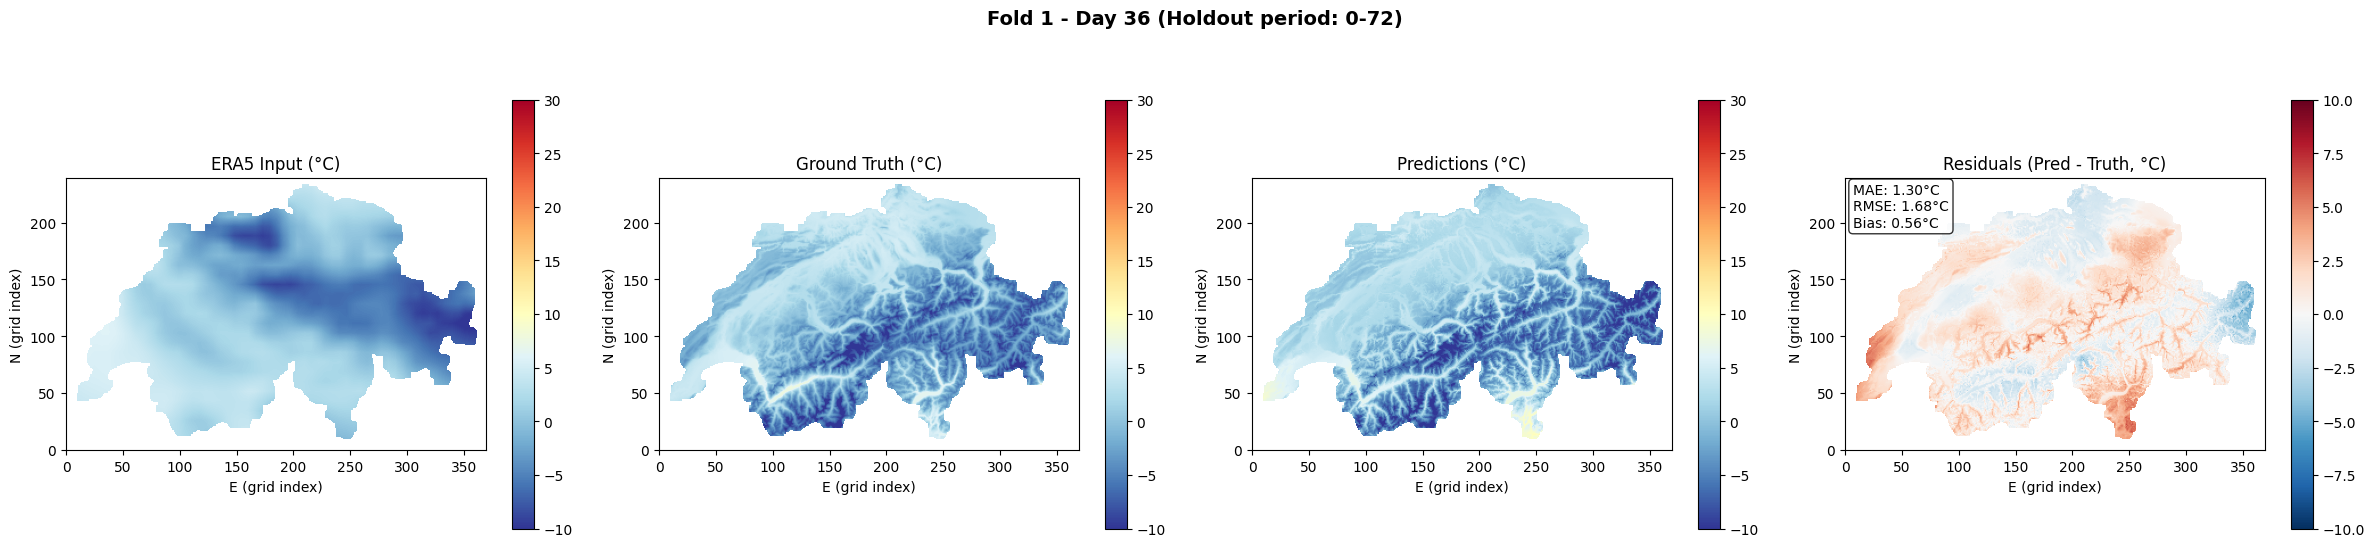


Fold 2/5
  Loaded model from epoch 26
  Holdout period: days 73 to 145 (73 days)
  Selected day index: 109


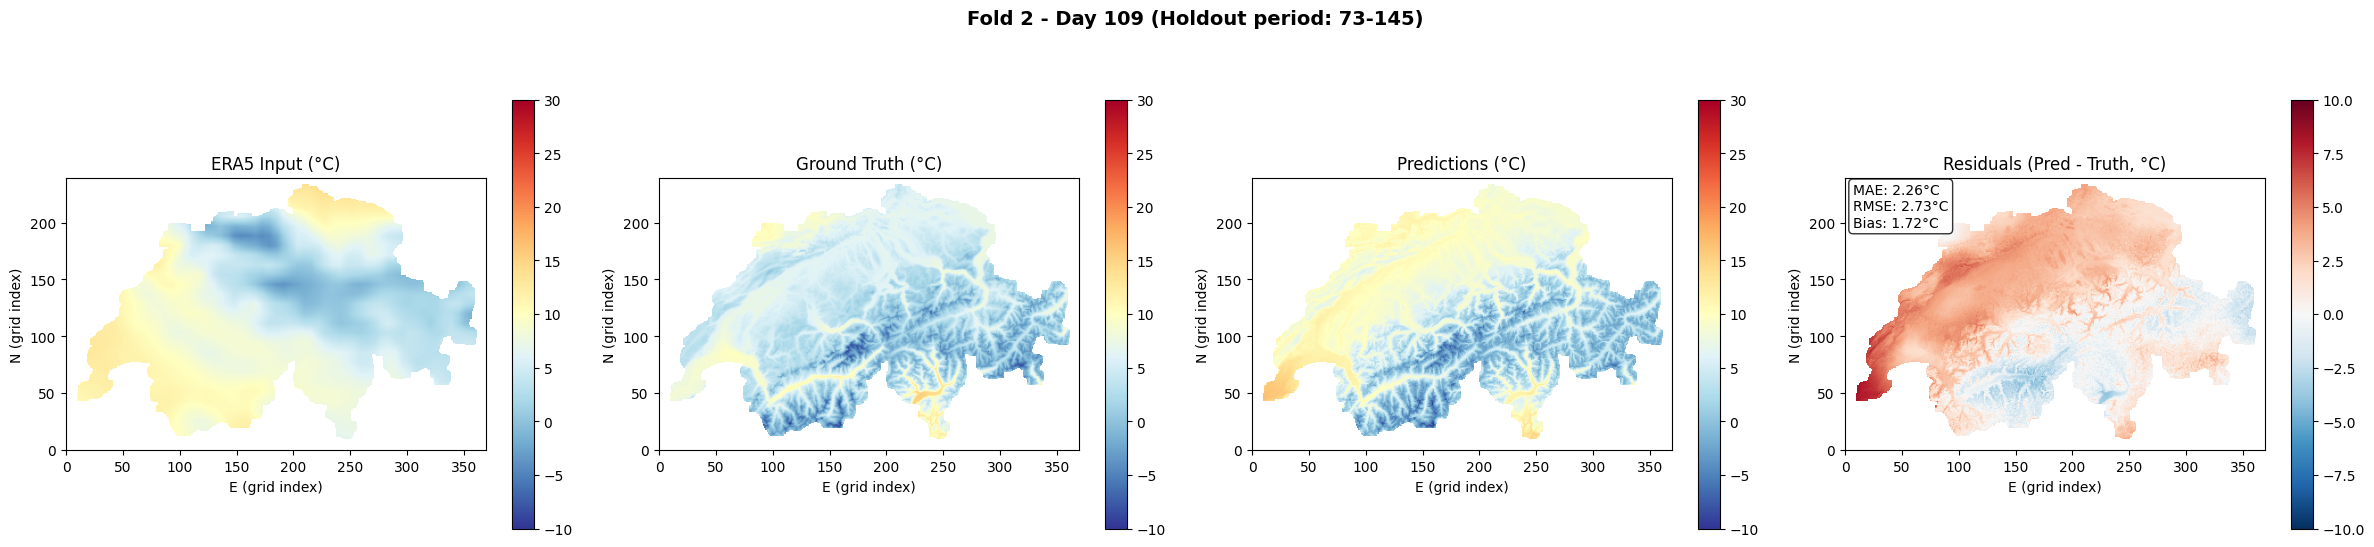


Fold 3/5
  Loaded model from epoch 29
  Holdout period: days 146 to 218 (73 days)
  Selected day index: 182


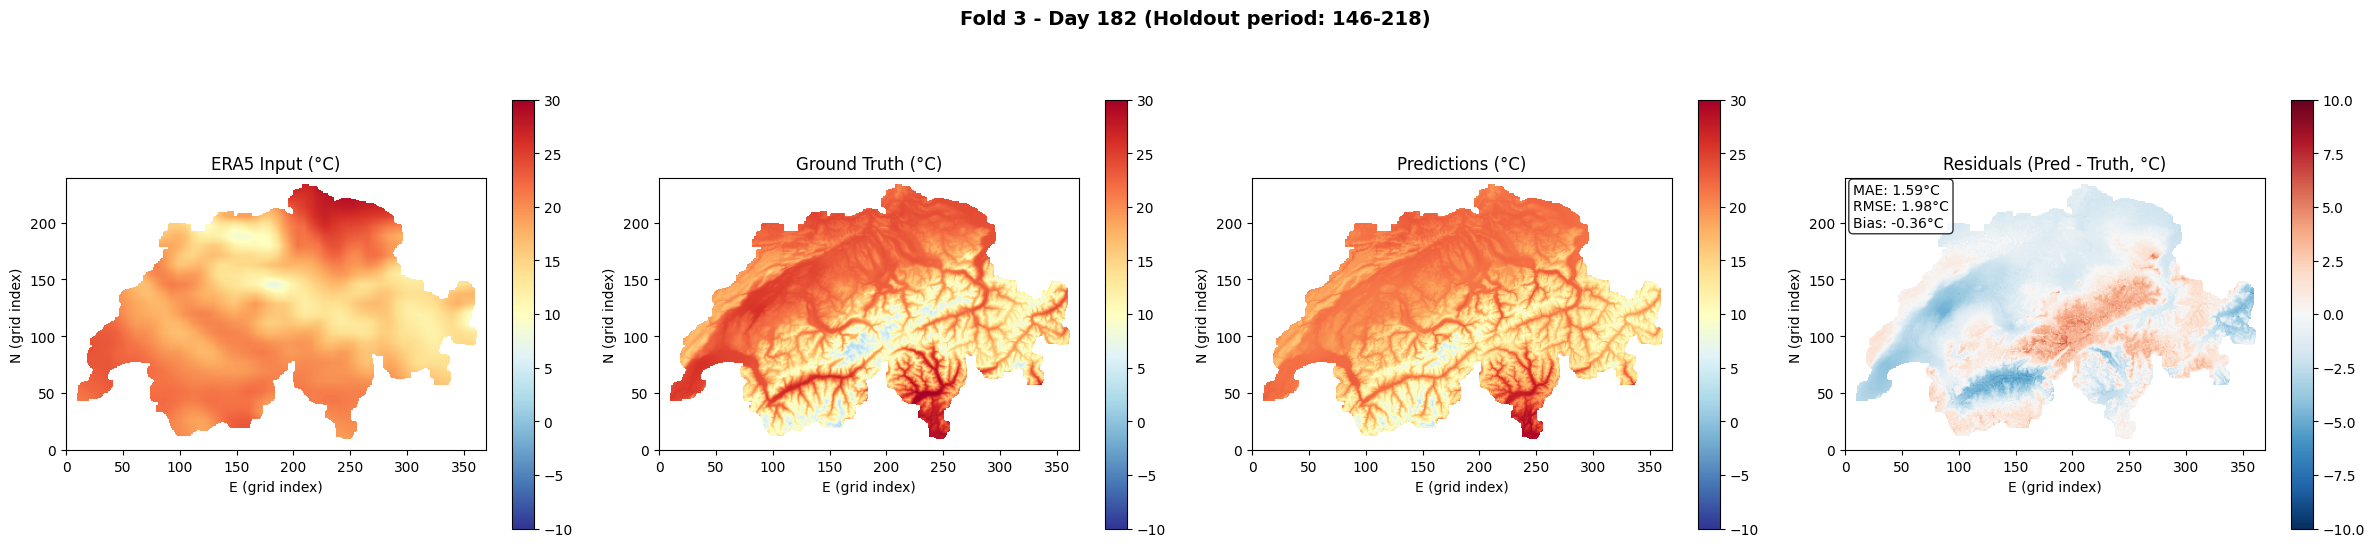


Fold 4/5
  Loaded model from epoch 25
  Holdout period: days 219 to 291 (73 days)
  Selected day index: 255


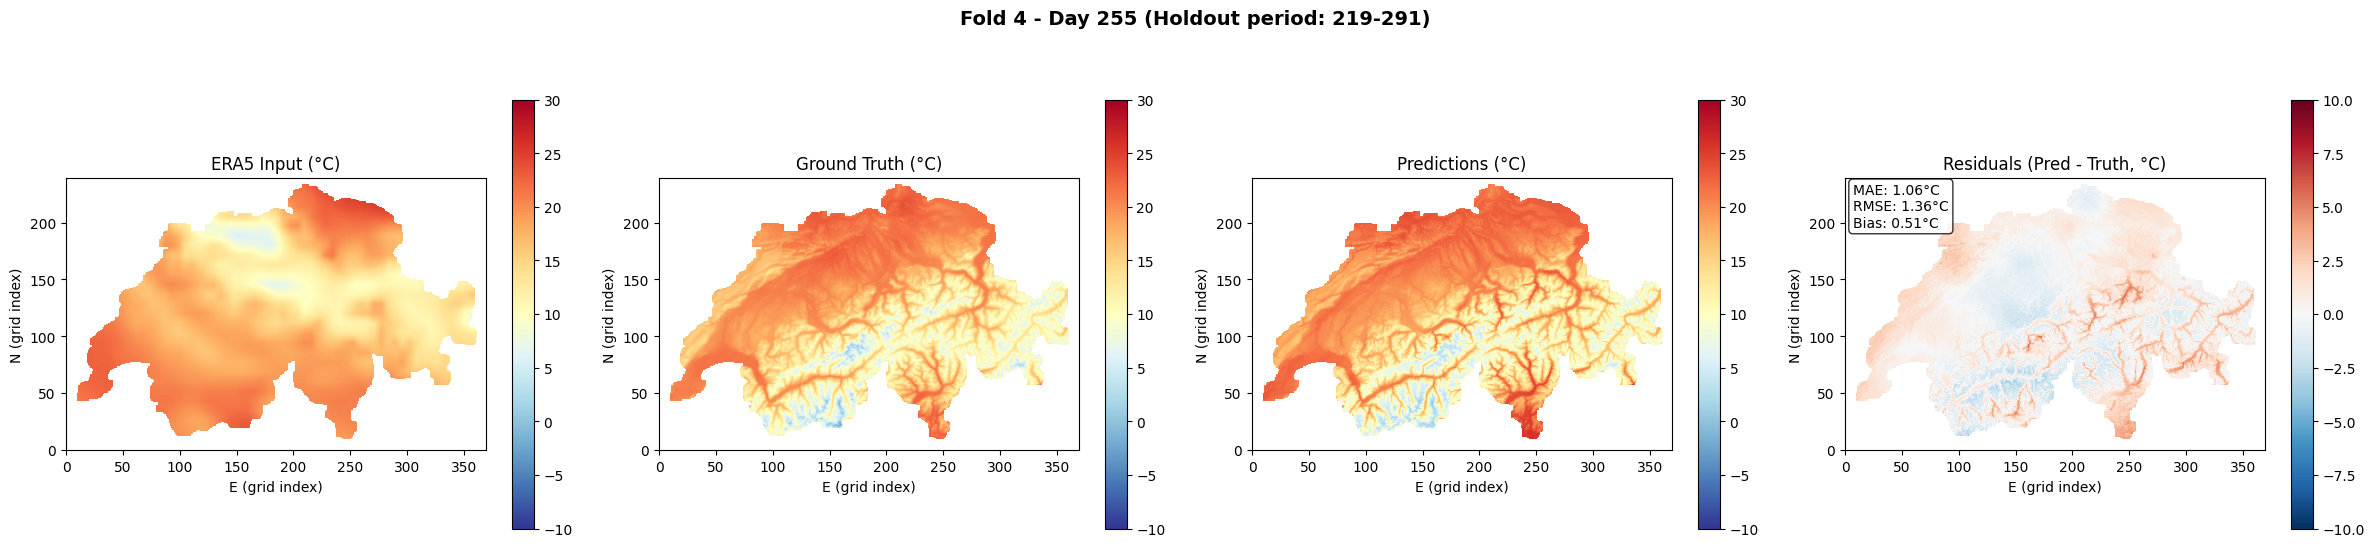


Fold 5/5
  Loaded model from epoch 28
  Holdout period: days 292 to 364 (73 days)
  Selected day index: 328


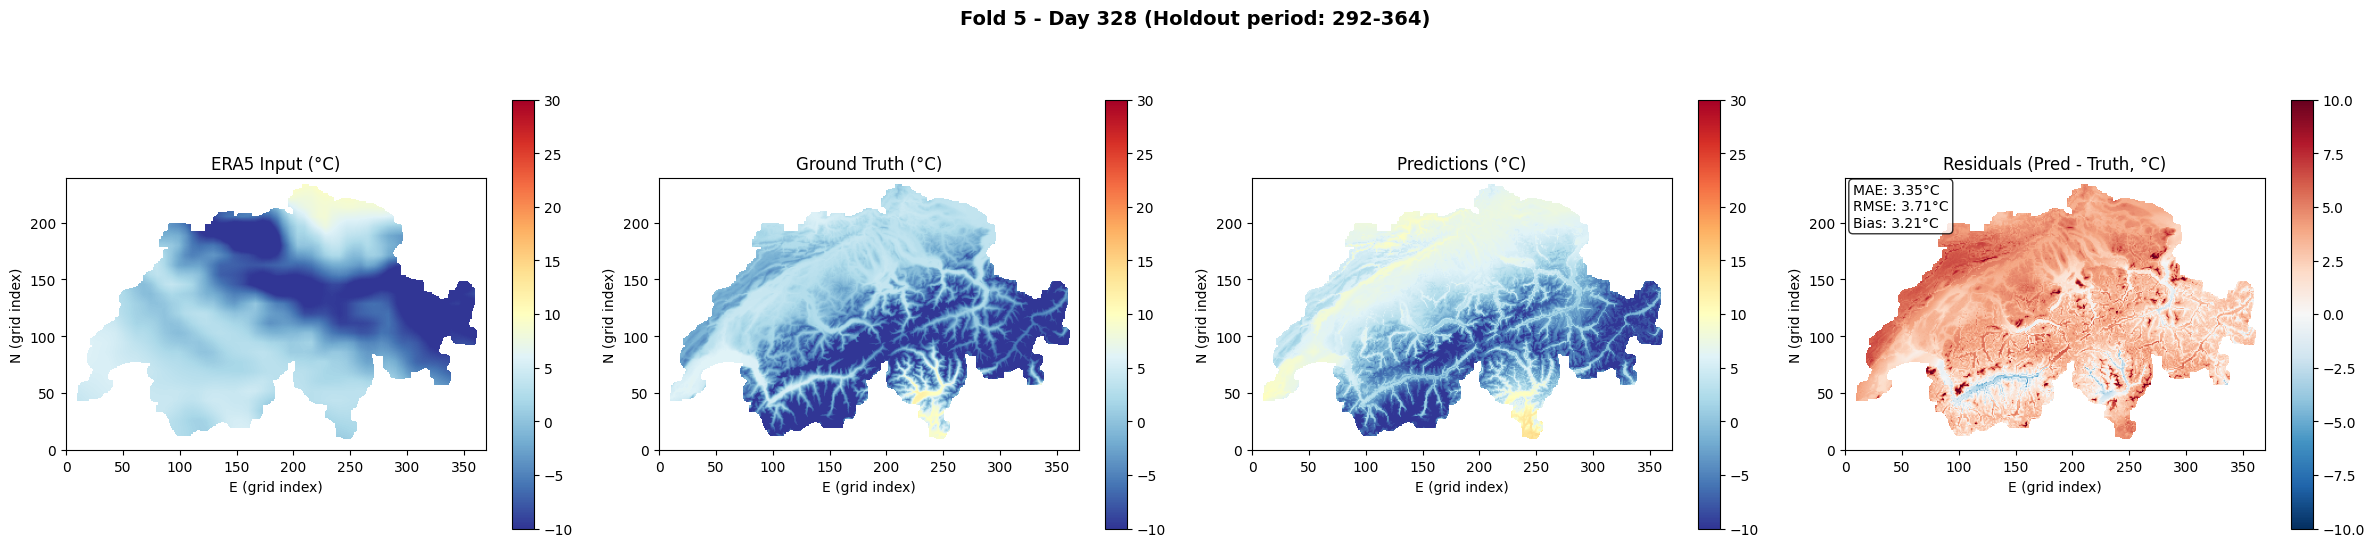

In [21]:
n_samples = era5_data.shape[0]
grid_shape = (grid_N, grid_E)
era5_shape = (era5_data.shape[2], era5_data.shape[3])  # (lat, lon)

print(f"Total time samples: {n_samples}")
print(f"Number of folds: {params.N_FOLDS}")
print(f"ERA5 grid shape: {era5_shape}")
print(f"MeteoSwiss grid shape: {grid_shape}")
print()

for fold in range(params.N_FOLDS):
    print(f"=" * 60)
    print(f"Fold {fold + 1}/{params.N_FOLDS}")
    print(f"=" * 60)
    
    # Load model checkpoint
    checkpoint_path = MODEL_DIR / f'model_fold_{fold}'
    if not checkpoint_path.exists():
        print(f"  Checkpoint not found: {checkpoint_path}")
        continue
    
    model, epoch = load_model_checkpoint(checkpoint_path, params, device)
    print(f"  Loaded model from epoch {epoch}")
    
    # Get holdout period for this fold
    holdout_start, holdout_end = get_fold_holdout_indices(fold, params.N_FOLDS, n_samples)
    print(f"  Holdout period: days {holdout_start} to {holdout_end-1} ({holdout_end - holdout_start} days)")
    
    # Select one day from holdout
    day_idx = select_holdout_day(fold, holdout_start, holdout_end, seed=params.SEED)
    print(f"  Selected day index: {day_idx}")
    
    # Generate predictions
    predictions = predict_single_day(model, era5_data, day_idx, dists, elev, device)
    predictions_np = predictions.cpu().numpy()
    
    # Get ground truth
    truth = target_y_tensor[day_idx].cpu().numpy()
    
    # Get ERA5 input temperature for this day (channel 0 is normalized temperature)
    era5_temp = era5_data[day_idx, 0].cpu().numpy()
    
    # Plot comparison
    title = f"Fold {fold + 1} - Day {day_idx} (Holdout period: {holdout_start}-{holdout_end-1})"
    fig = plot_prediction_comparison(
        truth=truth,
        predictions=predictions_np,
        era5_input=era5_temp,
        grid_shape=grid_shape,
        era5_shape=era5_shape,
        metadata=metadata,
        title=title,
        denormalize=True
    )
    plt.show()
    
    print()

## Summary

This notebook demonstrates how to:
1. Load a trained convCNP model using saved configuration
2. Reconstruct the holdout time periods used during cross-validation
3. Generate spatial predictions for the entire MeteoSwiss grid
4. Visualize predictions vs ground truth with residual analysis

The residual maps show where the model performs well (white) and where it struggles (blue=lower predictions, red=higher predictions).